# Part 4 — Luke Davis: Visualization & writeup

Load outputs from Parts 1, 2, 3

In [45]:
import re
import json
import statistics
import pickle
import io
import random

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from PIL import Image
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata

import pandas as pd
import numpy as np
import networkx as nx

with open("G.pkl", "rb") as f:
    G = pickle.load(f)

In [47]:
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "data" / "Raw Data and Growth Rate").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Could not locate project root containing data/Raw Data and Growth Rate/")

INPUT_DIR  = (PROJECT_ROOT / "data" / "Raw Data and Growth Rate" /
              "Interaction Calculation" / "Data" / "Data" / "input")
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

assert INPUT_DIR.is_dir(), f"input/ folder not found: {INPUT_DIR}"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"INPUT_DIR    = {INPUT_DIR}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = C:\Users\lukes\Downloads\CSBIO185_cell_mates
INPUT_DIR    = C:\Users\lukes\Downloads\CSBIO185_cell_mates\data\Raw Data and Growth Rate\Interaction Calculation\Data\Data\input
OUTPUT_DIR   = C:\Users\lukes\Downloads\CSBIO185_cell_mates\output


## Steepest-ascent walker animation

Random starting nodes, deterministic gradient steps, walker trails

In [40]:
def steepest_ascent_step(G, node):
    """
    From `node`, return the neighbor reachable by the steepest uphill edge.
    Considers both 'add' and 'remove' direction edges.
    Returns (next_node, gradient) or (None, 0) if already at local peak.
    """
    best_neighbor = None
    best_grad = 0.0  # only move if gradient is strictly positive

    for _, tgt, data in G.out_edges(node, data=True):
        if data["gradient"] > best_grad:
            best_grad = data["gradient"]
            best_neighbor = tgt

    return best_neighbor, best_grad


def run_walker(G, start_node, max_steps=50):
    """
    Run one steepest-ascent walker from start_node.
    Returns the full path as a list of node IDs.
    """
    path = [start_node]
    current = start_node

    for _ in range(max_steps):
        next_node, grad = steepest_ascent_step(G, current)
        if next_node is None:
            break  # local peak reached
        path.append(next_node)
        current = next_node

    return path

In [41]:
N_WALKERS = 20
MAX_STEPS = 30

all_nodes = list(G.nodes())

# Optional: seed from a specific size-level only (e.g., single drugs or pairs)
# start_pool = [n for n, d in G.nodes(data=True) if d["size"] == 1]
start_pool = all_nodes

random.seed(42)
start_nodes = random.sample(start_pool, min(N_WALKERS, len(start_pool)))

walker_paths = [run_walker(G, s, max_steps=MAX_STEPS) for s in start_nodes]

print(f"Walkers run: {len(walker_paths)}")
print(f"Peak nodes reached: {set(p[-1] for p in walker_paths)}")

Walkers run: 20
Peak nodes reached: {'CPR3+DOX2+ERY2+FOX1+FUS2', 'AMP2+CPR1+DOX1+ERY2+TMP3', 'DOX1+TMP3', 'CPR3+DOX3+ERY3+FUS3+TMP3', 'DOX1+ERY2+FOX2+FUS3+STR3', 'CPR2+DOX2+ERY2+FOX3+FUS1', 'CPR2+DOX3+ERY2+FUS3', 'AMP3+CPR2+DOX1+ERY2+TMP3', 'DOX3+TMP3', 'AMP1+DOX1+ERY2+FOX2+TMP1', 'CPR3+FOX3+FUS3+TMP2', 'AMP3+CPR2+DOX3+ERY1+TMP1', 'AMP3+CPR2+DOX2+ERY1+TMP3', 'DOX3+ERY3+FUS3', 'CPR2+DOX3+ERY3+FUS3+TMP1', 'CPR2+DOX2+ERY3+FUS3+TMP3', 'AMP2+CPR1+DOX3+ERY1+TMP2', 'AMP3+CPR3+ERY2+FUS3+TMP3'}


In [42]:
def build_layout(G):
    """
    Hierarchical layout: x = combination size, y = spread within that level.
    """
    by_size = {}
    for nid, data in G.nodes(data=True):
        by_size.setdefault(data["size"], []).append(nid)

    pos = {}
    for size, nodes in by_size.items():
        nodes_sorted = sorted(nodes)  # deterministic ordering
        n = len(nodes_sorted)
        for i, nid in enumerate(nodes_sorted):
            x = size
            y = (i - n / 2) / max(n, 1)  # normalize spread
            pos[nid] = (x, y)
    return pos

pos = build_layout(G)

In [43]:
max_frames = max(len(p) for p in walker_paths)

# Color each walker distinctly
walker_colors = plt.cm.tab20(np.linspace(0, 1, len(walker_paths)))

# Fitness range for node coloring
all_fitness = [d["fitness"] for _, d in G.nodes(data=True)]
fit_min, fit_max = min(all_fitness), max(all_fitness)

Render as animated GIF

In [44]:
def fitness_to_color(fitness, fit_min, fit_max, cmap=plt.cm.RdYlGn):
    norm = (fitness - fit_min) / (fit_max - fit_min + 1e-9)
    return cmap(norm)

frames = []
fig, ax = plt.subplots(figsize=(14, 8))

# --- Precompute static node positions and colors ---
node_list = list(G.nodes())
node_pos_arr = np.array([pos[n] for n in node_list])
node_colors = [fitness_to_color(G.nodes[n]["fitness"], fit_min, fit_max)
               for n in node_list]
node_sizes = [30 + G.nodes[n]["size"] * 20 for n in node_list]

for frame_idx in range(max_frames + 8):  # hold last frame a bit
    ax.clear()
    ax.set_facecolor("#0e0e1a")
    fig.patch.set_facecolor("#0e0e1a")

    # --- Draw all edges (faint) ---
    for src, tgt, data in G.edges(data=True):
        if data["direction"] != "add":
            continue  # draw only "add" direction to avoid clutter
        x0, y0 = pos[src]
        x1, y1 = pos[tgt]
        ax.plot([x0, x1], [y0, y1],
                color="gray", alpha=0.08, linewidth=0.4, zorder=1)

    # --- Draw all nodes ---
    sc = ax.scatter(node_pos_arr[:, 0], node_pos_arr[:, 1],
                    c=node_colors, s=node_sizes,
                    zorder=2, edgecolors="none", alpha=0.6)

    # --- Draw walker trails up to current frame ---
    for w_idx, path in enumerate(walker_paths):
        step = min(frame_idx, len(path) - 1)
        trail = path[:step + 1]

        if len(trail) < 2:
            # Just draw the starting dot
            x, y = pos[trail[0]]
            ax.scatter(x, y, s=80, color=walker_colors[w_idx],
                       zorder=5, edgecolors="white", linewidths=0.5)
            continue

        # Draw trail segments
        for i in range(len(trail) - 1):
            x0, y0 = pos[trail[i]]
            x1, y1 = pos[trail[i + 1]]
            alpha = 0.3 + 0.7 * (i / len(trail))  # fade in over time
            ax.annotate("",
                xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=walker_colors[w_idx],
                    lw=1.5,
                    alpha=alpha,
                    mutation_scale=10
                ),
                zorder=4
            )

        # Draw current walker head
        cx, cy = pos[trail[step]]
        ax.scatter(cx, cy, s=120, color=walker_colors[w_idx],
                   zorder=6, edgecolors="white", linewidths=1.0)

        # Mark starting node
        sx, sy = pos[trail[0]]
        ax.scatter(sx, sy, s=60, marker="^",
                   color=walker_colors[w_idx], zorder=5,
                   edgecolors="white", linewidths=0.5, alpha=0.7)

    # --- Highlight local peaks reached so far ---
    peaks_so_far = set()
    for path in walker_paths:
        step = min(frame_idx, len(path) - 1)
        if frame_idx >= len(path) - 1:
            peaks_so_far.add(path[-1])
    for peak in peaks_so_far:
        px, py = pos[peak]
        ax.scatter(px, py, s=250, marker="*",
                   color="gold", zorder=7, edgecolors="white", linewidths=0.8)

    # --- Labels ---
    ax.set_xlabel("Number of drugs in combination", color="white", fontsize=11)
    ax.set_title(f"Steepest-Ascent Walkers on Drug Fitness Landscape  |  Step {frame_idx}",
                 color="white", fontsize=12, pad=10)
    ax.set_xticks(range(6))
    ax.set_xticklabels(["0\n(no drug)", "1", "2", "3", "4", "5"],
                        color="white", fontsize=9)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor=plt.cm.RdYlGn(0.05), label="Low fitness (high killing)"),
        mpatches.Patch(facecolor=plt.cm.RdYlGn(0.95), label="High fitness (suppressive)"),
        plt.Line2D([0], [0], marker="*", color="gold", linestyle="None",
                   markersize=10, label="Local peak"),
        plt.Line2D([0], [0], marker="^", color="white", linestyle="None",
                   markersize=7, label="Walker start"),
    ]
    ax.legend(handles=legend_elements, loc="upper left",
              facecolor="#1a1a2e", labelcolor="white", fontsize=8)

    # Capture frame
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()

plt.close(fig)

# --- Save GIF ---
frames[0].save(
    "walker_animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,   # ms per frame — increase to slow down
    loop=0
)
print("Saved walker_animation.gif")

Saved walker_animation.gif


In [54]:
# Use NetworkX spring layout for 2D embedding
# (undirected view so layout is symmetric)
U = G.to_undirected()
pos2d = nx.spring_layout(U, seed=42, k=0.4, iterations=80)

# Extract (x, y, fitness) for every node
points_x, points_y, points_z = [], [], []
for nid, data in G.nodes(data=True):
    x, y = pos2d[nid]
    points_x.append(x)
    points_y.append(y)
    points_z.append(data["fitness"])

points_x = np.array(points_x)
points_y = np.array(points_y)
points_z = np.array(points_z)

low_clip  = np.percentile(points_z, 5)   # adjust percentile as needed
high_clip = np.percentile(points_z, 95)  # optional, clips high end too
points_z_clipped = np.clip(points_z, low_clip, high_clip)

# Interpolate onto a regular grid for surface plotting
grid_res = 80
xi = np.linspace(points_x.min(), points_x.max(), grid_res)
yi = np.linspace(points_y.min(), points_y.max(), grid_res)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((points_x, points_y), points_z_clipped, (Xi, Yi), method="cubic")

# Fill any NaN edges from cubic interpolation
Zi_linear = griddata((points_x, points_y), points_z_clipped, (Xi, Yi), method="linear")
nan_mask = np.isnan(Zi)
Zi[nan_mask] = Zi_linear[nan_mask]

In [55]:
def steepest_ascent_step(G, node):
    best, best_grad = None, 0.0
    for _, tgt, data in G.out_edges(node, data=True):
        if data["gradient"] > best_grad:
            best_grad = data["gradient"]
            best = tgt
    return best

def run_walker(G, start, max_steps=40):
    path = [start]
    cur = start
    for _ in range(max_steps):
        nxt = steepest_ascent_step(G, cur)
        if nxt is None:
            break
        path.append(nxt)
        cur = nxt
    return path

N_WALKERS = 12
random.seed(42)
starts = random.sample(list(G.nodes()), N_WALKERS)
walker_paths = [run_walker(G, s) for s in starts]

# Map each walker node to (x, y, z) using pos2d
def path_to_xyz(path):
    xs = [pos2d[n][0] for n in path]
    ys = [pos2d[n][1] for n in path]
    zs = [G.nodes[n]["fitness"] for n in path]
    return np.array(xs), np.array(ys), np.array(zs)

In [56]:
walker_colors = plt.cm.tab10(np.linspace(0, 1, N_WALKERS))
max_frames = max(len(p) for p in walker_paths)
frames = []

# Rotating camera angles for cinematic effect (optional)
# Set to fixed values if you want a static viewpoint
ELEV = 30
AZIM_START = -60

for frame_idx in range(max_frames + 6):
    fig = plt.figure(figsize=(11, 7), facecolor="#0a0a14")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("#0a0a14")

    # --- Surface ---
    surf = ax.plot_surface(
        Xi, Yi, Zi,
        cmap="RdYlGn",          # red=low fitness, green=high (matches paper)
        alpha=0.75,
        linewidth=0,
        antialiased=True,
        vmin=np.nanmin(Zi),
        vmax=np.nanmax(Zi)
    )

    # Wireframe overlay for the "landscape mesh" look from Fig 2
    ax.plot_wireframe(
        Xi, Yi, Zi,
        color="white", alpha=0.06,
        linewidth=0.3, rstride=4, cstride=4
    )

    # --- Walker trails ---
    for w_idx, path in enumerate(walker_paths):
        step = min(frame_idx, len(path) - 1)
        trail = path[:step + 1]
        wx, wy, wz = path_to_xyz(trail)

        # Lift walkers slightly above surface so they're visible
        wz_lifted = wz + (np.nanmax(Zi) - np.nanmin(Zi)) * 0.02

        if len(trail) > 1:
            ax.plot(wx, wy, wz_lifted,
                    color=walker_colors[w_idx],
                    linewidth=2.5, alpha=0.9, zorder=5)

        # Walker head
        ax.scatter(wx[-1], wy[-1], wz_lifted[-1],
                   color=walker_colors[w_idx], s=60,
                   edgecolors="white", linewidths=0.8, zorder=6)

        # Start marker
        ax.scatter(wx[0], wy[0], wz_lifted[0],
                   marker="^", color=walker_colors[w_idx],
                   s=40, alpha=0.6, zorder=5)

        # Gold star at peak (once walker has stopped)
        if frame_idx >= len(path) - 1:
            ax.scatter(wx[-1], wy[-1], wz_lifted[-1],
                       marker="*", color="gold", s=180,
                       edgecolors="white", linewidths=0.5, zorder=7)

    # --- Colorbar ---
    cbar = fig.colorbar(surf, ax=ax, shrink=0.45, pad=0.02,
                        label="Relative bacterial fitness (%)")
    cbar.ax.yaxis.label.set_color("white")
    cbar.ax.tick_params(colors="white")

    # --- Rotate view slightly each frame for depth ---
    azim = AZIM_START + frame_idx * 1.2  # comment out for static view
    ax.view_init(elev=ELEV, azim=azim)

    ax.set_xlabel("Drug combination space", color="white", labelpad=8)
    ax.set_ylabel("", color="white")
    ax.set_zlabel("Fitness", color="white", labelpad=6)
    ax.tick_params(colors="white")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#222244")
    ax.yaxis.pane.set_edgecolor("#222244")
    ax.zaxis.pane.set_edgecolor("#222244")
    ax.grid(False)

    ax.set_title(
        f"Steepest-Ascent Walkers on Drug Fitness Landscape  |  Step {frame_idx}",
        color="white", fontsize=11, pad=12
    )

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)

frames[0].save(
    "walker_3d_animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)
print("Saved walker_3d_animation.gif")

Saved walker_3d_animation.gif


## Final figures

Polish lattice plot and box and whisker from Part 1 to publication quality

In [33]:
with open("lookup.pkl", "rb") as f:
    lookup = pickle.load(f)

# Pick AMP+CPR+ERY+FUS+TMP at peak dose for all five drugs
focal = ["AMP", "CPR", "ERY", "FUS", "TMP"]
focal_set = frozenset(focal)
doses = {d: 3 for d in focal}

slice_nodes = []
for s in lookup:
    if not s.issubset(focal_set):
        continue
    rec = lookup[s].get(tuple(sorted((d, doses[d]) for d in s)))
    if rec is None:
        continue
    slice_nodes.append((s, rec["mean"]))
print(f"Subsets in this slice: {len(slice_nodes)}")

Subsets in this slice: 31


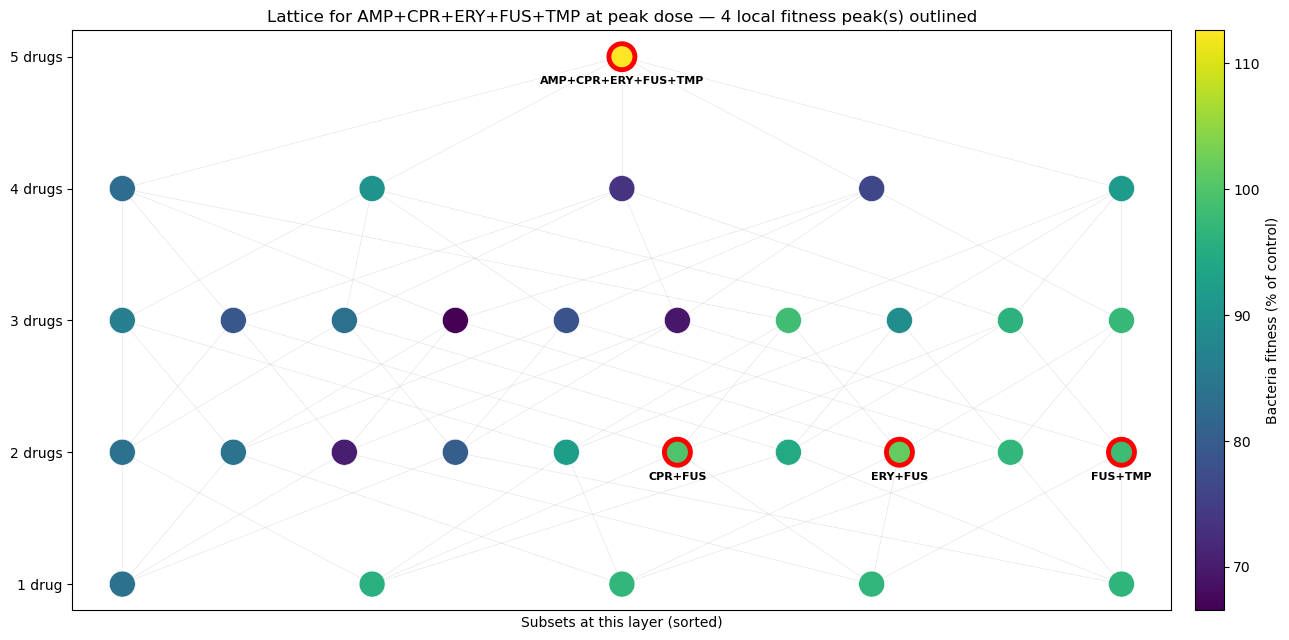

In [34]:
fit_map = {s: f for s, f in slice_nodes}
valleys = set()
for s, fs in slice_nodes:
    nbrs = [fit_map[t] for t in fit_map if len(s.symmetric_difference(t)) == 1]
    if nbrs and all(ft <= fs + 1e-9 for ft in nbrs):
        valleys.add(s)

by_size_local = {}
for s, _ in slice_nodes:
    by_size_local.setdefault(len(s), []).append(s)
pos = {}
for sz, items in by_size_local.items():
    items_sorted = sorted(items, key=lambda s: tuple(sorted(s)))
    n = len(items_sorted)
    for i, s in enumerate(items_sorted):
        x = (i - (n - 1) / 2) / max(n - 1, 1) if n > 1 else 0.0
        pos[s] = (x, sz)

xs = np.array([pos[s][0] for s, _ in slice_nodes])
ys = np.array([pos[s][1] for s, _ in slice_nodes])
fits = np.array([f for _, f in slice_nodes])

fig, ax = plt.subplots(figsize=(13, 6.5))
for s, _ in slice_nodes:
    for t, _ in slice_nodes:
        if t.issuperset(s) and len(t) - len(s) == 1:
            ax.plot([pos[s][0], pos[t][0]], [pos[s][1], pos[t][1]],
                    color="#cccccc", lw=0.4, alpha=0.6, zorder=1)

edge_widths = [3.5 if s in valleys else 0.4 for s, _ in slice_nodes]
edge_colors = ["red" if s in valleys else "white" for s, _ in slice_nodes]
sc = ax.scatter(xs, ys, c=fits, cmap="viridis", s=350,
                edgecolors=edge_colors, linewidths=edge_widths, zorder=2)
for s, _ in slice_nodes:
    if s in valleys:
        ax.text(pos[s][0], pos[s][1] - 0.15, "+".join(sorted(s)),
                fontsize=8, ha="center", va="top", color="black", zorder=3, weight = 'bold')
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Bacteria fitness (% of control)")
ax.set_yticks(sorted(by_size_local))
ax.set_yticklabels([f"{k} drug{'s' if k != 1 else ''}" for k in sorted(by_size_local)])
ax.set_xticks([])
ax.set_xlabel("Subsets at this layer (sorted)")
ax.set_title(f"Lattice for {'+'.join(focal)} at peak dose — "
             f"{len(valleys)} local fitness peak(s) outlined")
plt.tight_layout()
plt.show()

ax.figure.savefig('part1_lattice_example.png', dpi=300)

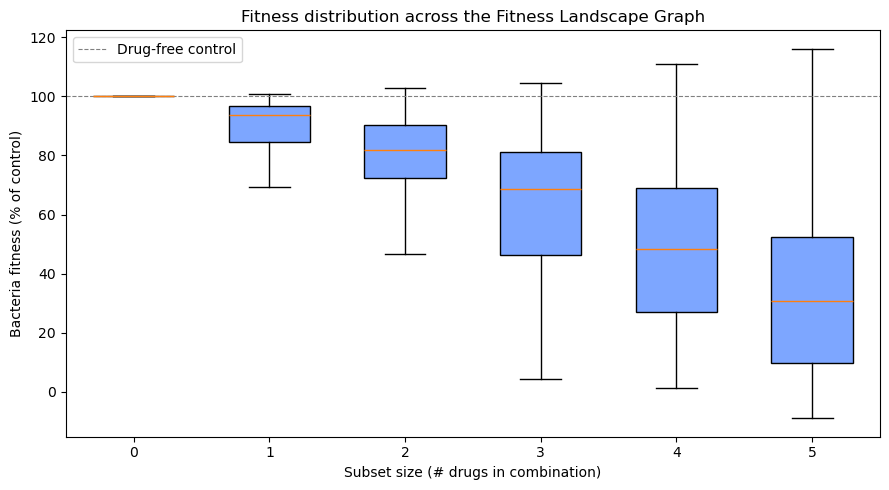

In [14]:
with open("G.pkl", "rb") as f:
    G = pickle.load(f)

fit_by_size = defaultdict(list)
for _, data in G.nodes(data=True):
    fit_by_size[data["size"]].append(data["fitness"])

sizes = sorted(fit_by_size)
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([fit_by_size[s] for s in sizes], positions=sizes,
                widths=0.6, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#7da6ff")
ax.axhline(100, color="gray", ls="--", lw=0.8, label="Drug-free control")
ax.set_xticks(sizes)
ax.set_xlabel("Subset size (# drugs in combination)")
ax.set_ylabel("Bacteria fitness (% of control)")
ax.set_title("Fitness distribution across the Fitness Landscape Graph")
ax.legend()
plt.tight_layout()
plt.show()

ax.figure.savefig('part1_boxplot.png', dpi=300)

Polish basin bar chart and drug composition heatmap from Part 2

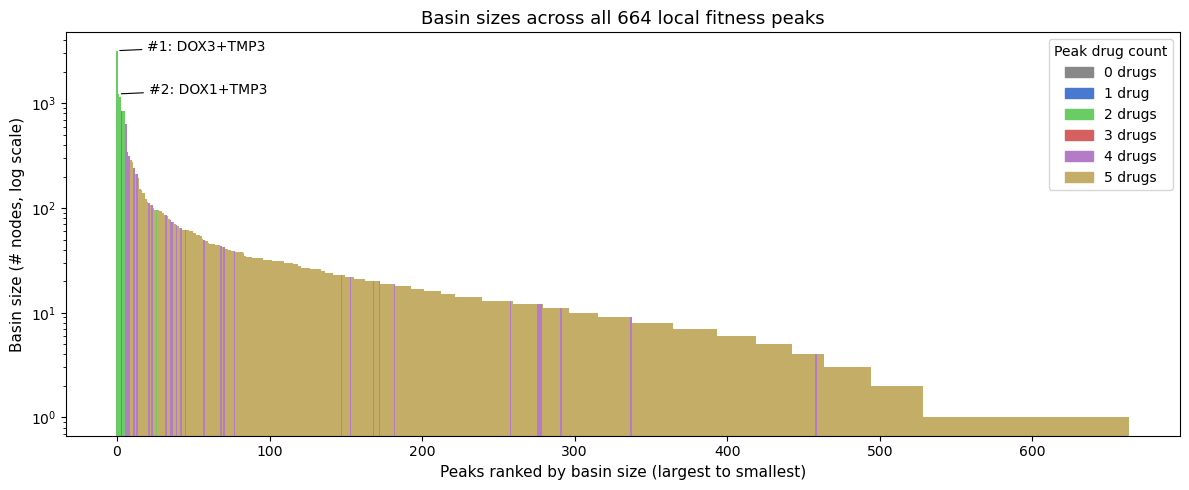

In [26]:
with open("ranked_peaks.pkl", "rb") as f:
    ranked_peaks = pickle.load(f)

DRUG_COUNT_COLORS = {
    0: "#888888",
    1: "#4878CF",
    2: "#6ACC65",
    3: "#D65F5F",
    4: "#B47CC7",
    5: "#C4AD66",
}

peak_ids    = [pk for pk, _ in ranked_peaks]
basin_sizes = [len(members) for _, members in ranked_peaks]
bar_colors  = [DRUG_COUNT_COLORS.get(G.nodes[pk]["size"], "#cccccc") for pk in peak_ids]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(peak_ids)), basin_sizes, color=bar_colors, width=1.0, linewidth=0)
ax.set_yscale("log")
ax.set_xlabel("Peaks ranked by basin size (largest to smallest)", fontsize=11)
ax.set_ylabel("Basin size (# nodes, log scale)", fontsize=11)
ax.set_title(f"Basin sizes across all {len(ranked_peaks)} local fitness peaks", fontsize=13)

legend_handles = [
    Patch(color=DRUG_COUNT_COLORS[k], label=f"{k} drug{'s' if k != 1 else ''}")
    for k in sorted(DRUG_COUNT_COLORS)
]
ax.legend(handles=legend_handles, title="Peak drug count",
          loc="upper right", fontsize=10, title_fontsize=10)

for rank_i in range(min(2, len(ranked_peaks))):
    offset = max(len(ranked_peaks) * 0.03, 1)
    ax.annotate(
        f"#{rank_i + 1}: {peak_ids[rank_i]}",
        xy=(rank_i, basin_sizes[rank_i]),
        xytext=(rank_i + offset, basin_sizes[rank_i] * 1),
        fontsize=10, arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "basin_size_distribution.png", dpi=150)
plt.show()

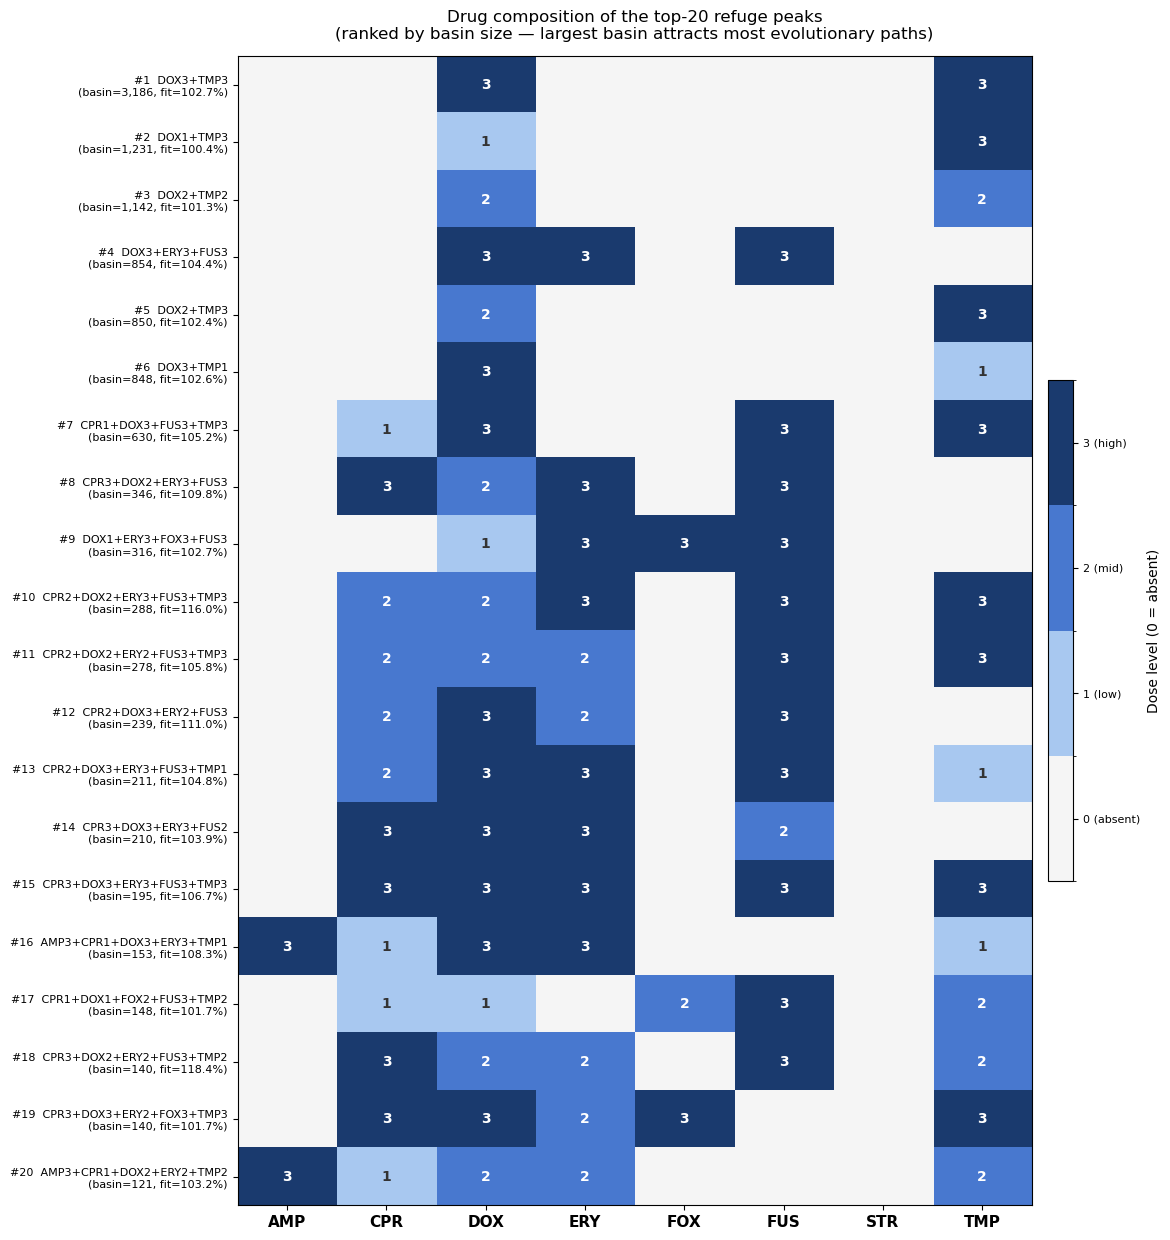

In [31]:
with open("basins.pkl", "rb") as f:
    basins = pickle.load(f)

with open("ALL_DRUGS.pkl", "rb") as f:
    ALL_DRUGS = pickle.load(f)

TOP_N = 20
top_peaks  = [pk for pk, _ in ranked_peaks[:TOP_N]]
top_labels = [
    f"#{i+1}  {pk}\n(basin={len(basins[pk]):,}, fit={G.nodes[pk]['fitness']:.1f}%)"
    for i, pk in enumerate(top_peaks)
]

mat = np.zeros((len(top_peaks), len(ALL_DRUGS)), dtype=float)
for r, pk in enumerate(top_peaks):
    dose_map = dict(G.nodes[pk]["dose"])
    for c, drug in enumerate(ALL_DRUGS):
        mat[r, c] = dose_map.get(drug, 0)

cmap_colors = ["#f5f5f5", "#a8c8f0", "#4878CF", "#1a3a6e"]
cmap   = mcolors.ListedColormap(cmap_colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(len(ALL_DRUGS) * 1.1 + 3, TOP_N * 0.55 + 1.5))
im = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(ALL_DRUGS)))
ax.set_xticklabels(ALL_DRUGS, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(top_peaks)))
ax.set_yticklabels(top_labels, fontsize=8)

for r in range(len(top_peaks)):
    for c in range(len(ALL_DRUGS)):
        val = int(mat[r, c])
        if val > 0:
            ax.text(c, r, str(val), ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if val >= 2 else "#333333")

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.03, pad=0.02)
cbar.set_label("Dose level (0 = absent)", fontsize=10)
cbar.ax.set_yticklabels(["0 (absent)", "1 (low)", "2 (mid)", "3 (high)"], fontsize=8)

ax.set_title(
    f"Drug composition of the top-{TOP_N} refuge peaks\n"
    "(ranked by basin size — largest basin attracts most evolutionary paths)",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "refuge_composition_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Polish MOA enrichment heatmap from Part 3

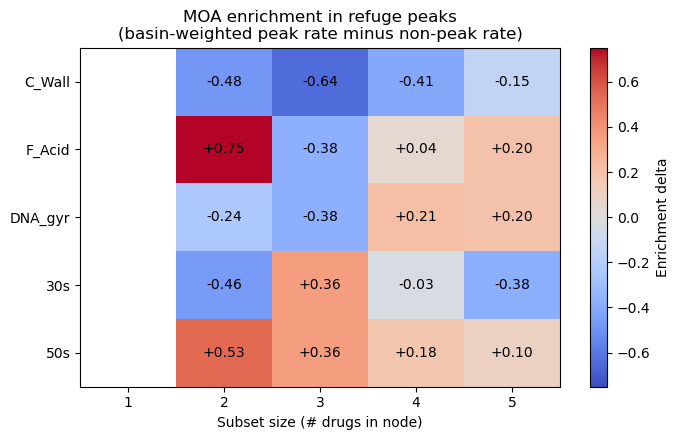

In [37]:
with open("enrichment_table.pkl", "rb") as f:
    enrichment_table = pickle.load(f)

DRUGS = ["AMP", "CPR", "DOX", "ERY", "FOX", "FUS", "STR", "TMP"]
MOA_COLS = ["C_Wall", "F_Acid", "DNA_gyr", "30s", "50s"]

# Mapping that exactly reproduces the authors' SINGLES_MOA*.csv encoding.
# Note that this is the paper/data encoding used for validation and downstream comparison.
DRUG_TO_MOA = {
    "AMP": "C_Wall",
    "CPR": "DNA_gyr",
    "DOX": "50s",
    "ERY": "50s",
    "FOX": "C_Wall",
    "FUS": "30s",
    "STR": "30s",
    "TMP": "F_Acid",
}

heatmap_data = enrichment_table.pivot(
    index="moa",
    columns="subset_size",
    values="basin_weighted_enrichment_delta",
).reindex(MOA_COLS)

fig, ax = plt.subplots(figsize=(7, 4.5))
max_abs = np.nanmax(np.abs(heatmap_data.to_numpy()))
im = ax.imshow(heatmap_data, cmap="coolwarm", vmin=-max_abs, vmax=max_abs, aspect="auto")
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Subset size (# drugs in node)")
ax.set_title("MOA enrichment in refuge peaks\n(basin-weighted peak rate minus non-peak rate)")

for i, moa in enumerate(heatmap_data.index):
    for j, subset_size in enumerate(heatmap_data.columns):
        value = heatmap_data.loc[moa, subset_size]
        if not np.isnan(value):
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment delta")
plt.tight_layout()
plt.show()

## Writeup integration

Markdown narrative tying basins, MOA, and topology together